Built a seperate notebook to showcase how to load and use the trained model.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
import numpy as np
import matplotlib.pyplot as plt
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchsummary import summary
from tqdm import tqdm
import sys


sys.path.insert(0,'..')
from training import predict

In [2]:
class LensingNpyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for idx, cl in enumerate(self.classes):
            class_path = os.path.join(root_dir, cl)
            if not os.path.isdir(class_path):
                continue
            for f in os.listdir(class_path):
                if f.endswith('.npy'):
                    self.data.append((os.path.join(class_path, f), idx))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = np.load(img_path).astype(np.float32)
        if image.shape[0] == 1:
            image = image.squeeze(0)
        image = torch.from_numpy(image).unsqueeze(0)
        if self.transform:
            image = self.transform(image)
        return image, label


Loading Trained Model

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

MODEL_PATH = "DeepLense_Gravitational_Lensing_Results/resnet50_lensing_final.pth"
CLASSES = ['no', 'sphere', 'vort']

# Reconstruct the modified ResNet50 architecture from classify.ipynb
model = models.resnet50(weights=None)

# Replace conv1 to accept 1-channel (grayscale) input
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Replace the final FC layer with the custom classification head
in_features = model.fc.in_features
final_layer = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(CLASSES))
)
model.fc = final_layer

# Load saved weights
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f"Device: {device}")
print(f"Loaded ResNet50 model from '{MODEL_PATH}'")
print(f"Classes: {CLASSES}")


Device: cuda
Loaded ResNet50 model from 'DeepLense_Gravitational_Lensing_Results/resnet50_lensing_final.pth'
Classes: ['no', 'sphere', 'vort']


Setting up transform for Test Set

In [4]:
transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])


Loading test data for evaluation

In [5]:
test_dir = os.path.join('dataset', 'val')
test_dataset = LensingNpyDataset(root_dir=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


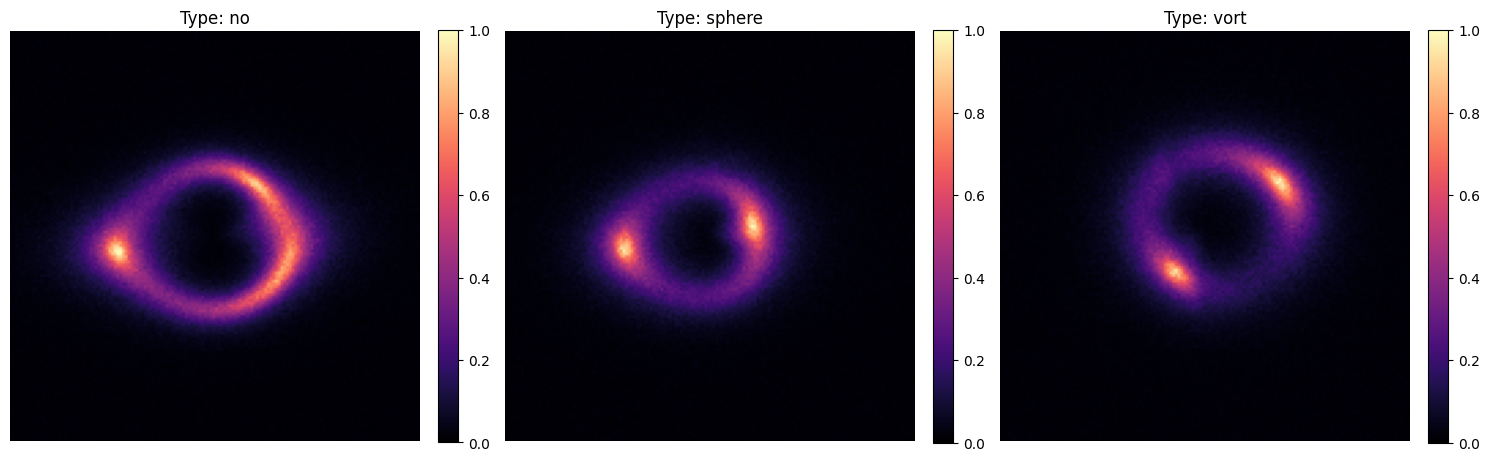

In [6]:
classes = ['no','sphere','vort']
fig, axes = plt.subplots(1,3, figsize=(15,5))

for i,cl in enumerate(CLASSES):
    class_path = os.path.join(test_dir,cl)
    file_name = [f for f in os.listdir(class_path) if f.endswith('.npy')][0]
    img_array = np.load(os.path.join(class_path,file_name))
    
    im=axes[i].imshow(img_array.squeeze(),cmap='magma')
    axes[i].set_title(f"Type: {cl}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    
plt.tight_layout()
plt.show()

Running Predictions on Test set

In [7]:
probabilities=predict(model, test_loader, device)
predictions=torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/235 [00:00<?, ?it/s]

Confusion Matrix On Test Set

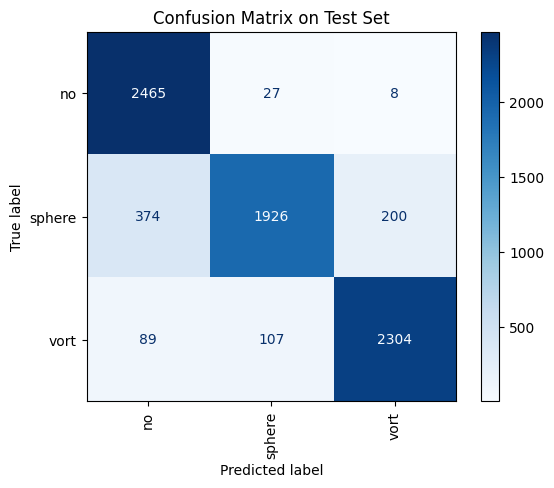

In [8]:
targets=[]

for _, labels in test_loader:
    targets.extend(labels.cpu().numpy())
    
cm=confusion_matrix(targets, predictions.cpu().numpy())
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'sphere', 'vort'])
disp.plot(cmap='Blues', xticks_rotation="vertical")
plt.title("Confusion Matrix on Test Set")
plt.show()

In [9]:
def plot_final_roc(model, dataloader, device, classes, title_suffix=""):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Binarize labels for multiclass ROC
    n_classes = len(classes)
    y_test = label_binarize(all_labels, classes=range(n_classes))
    
    plt.figure(figsize=(8, 6))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curve - {title_suffix}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

ROC Curves for all 3 classes

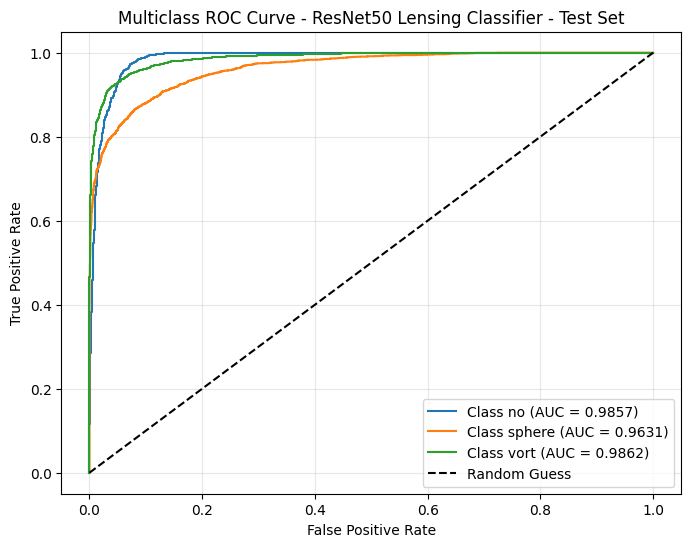

In [10]:
plot_final_roc(model, test_loader, device, CLASSES, "ResNet50 Lensing Classifier - Test Set")
